### imports

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

### datasets

In [2]:
df = pd.read_csv("../data/india_job_market_2024_2026.csv")

### analysis

In [3]:
grouped = df.groupby(['Job_Title'])

dataset = grouped.Salary_LPA.mean()

dataset = dataset.sort_values()

dataset2 = grouped.apply(lambda x: x.Job_ID.loc[x.Experience_Level =='Fresher (0-1 yr)'].count())

dataset2 = dataset2.sort_values()

dataset4 = df.groupby('Job_Title').Applicants.mean().sort_values()

df.shape

df.dtypes

exp_mapping = {
    'Fresher (0-1 yr)': 1,
    'Junior (1-3 yrs)': 2,
    'Mid (3-6 yrs)': 3,
    'Senior (6-10 yrs)': 4,
    'Lead (10+ yrs)': 5
}

df['Experience_Numeric'] = df['Experience_Level'].map(exp_mapping)

numeric_cols = df.select_dtypes(include=['number']).columns.drop('Salary_LPA')
X = df[numeric_cols]
y = df.Salary_LPA



In [4]:
dataset3 = df.groupby('Job_Title').Experience_Level.value_counts(normalize=True)*100
result = dataset3.loc[(slice(None), "Fresher (0-1 yr)")]
result = result.sort_values()

### modeling


In [5]:
job_model = DecisionTreeRegressor(random_state=1)

job_model.fit(X,y)

predictions = job_model.predict(X)




### visualization

<Axes: title={'center': 'Mean salary for every computer science role'}, xlabel='Job_Title', ylabel='Average Salary per year (in Lakhs)'>

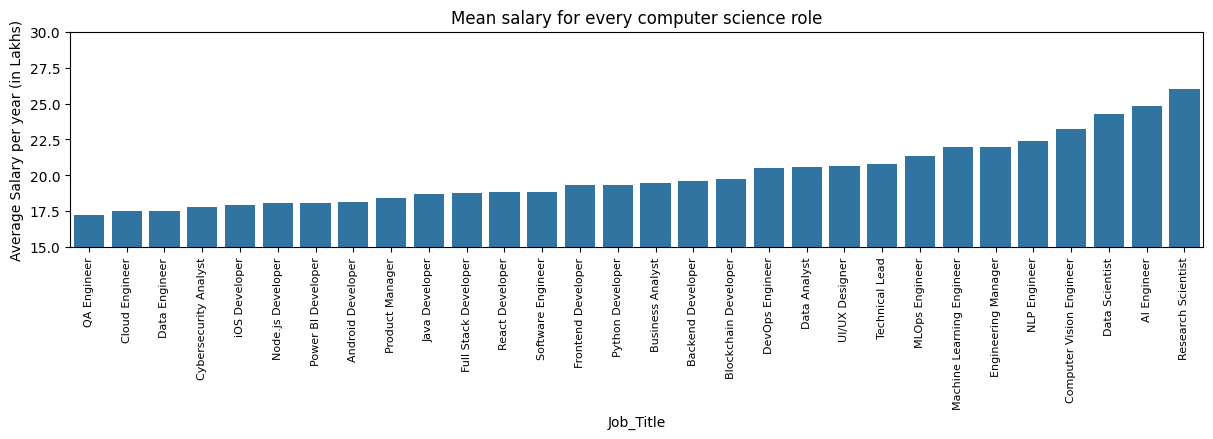

In [6]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Mean salary for every computer science role")
plt.ylim(15, 30)
plt.ylabel("Average Salary per year (in Lakhs)")
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset)

<Axes: title={'center': 'Number of fresher jobs per CS role'}, xlabel='Job_Title'>

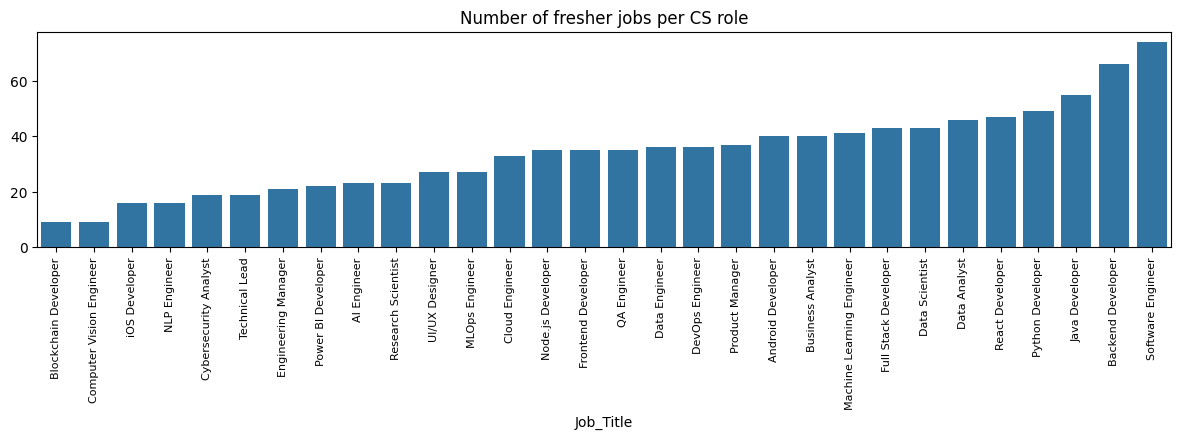

In [7]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Number of fresher jobs per CS role")
#plt.ylim(15, 30)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset2)

<Axes: title={'center': 'Percent of fresher jobs per CS role'}, xlabel='Job_Title', ylabel='proportion'>

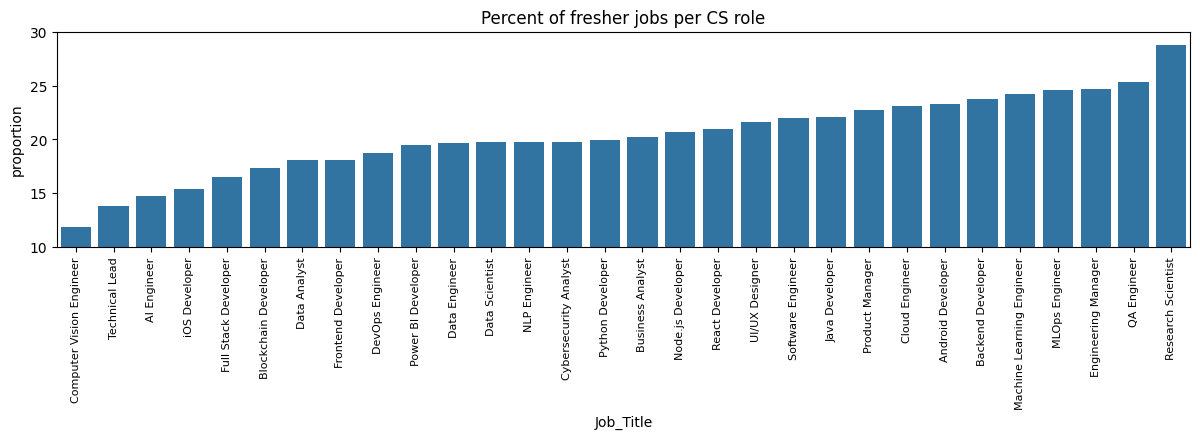

In [8]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Percent of fresher jobs per CS role")
plt.ylim(10, 30)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = result)

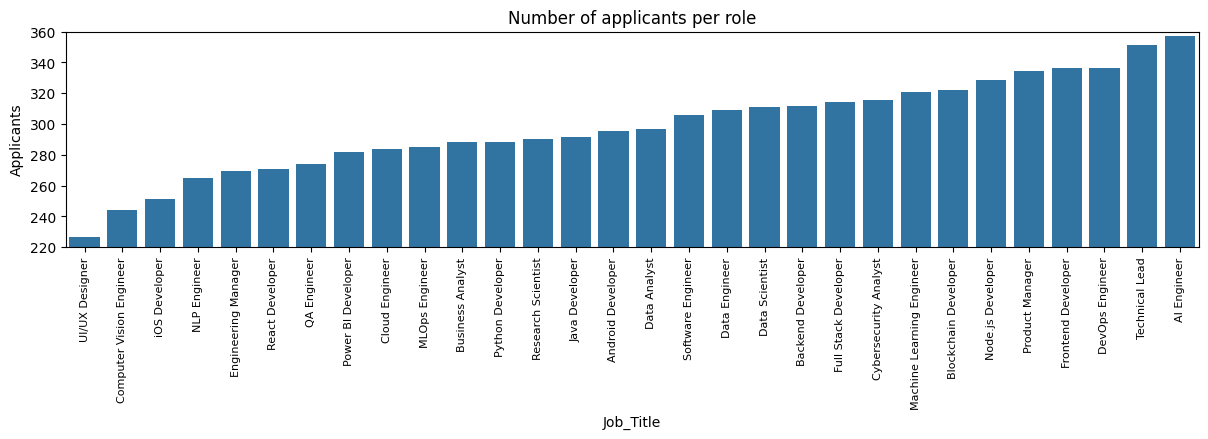

In [9]:
plt.figure(figsize=(12, 4))
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.title("Number of applicants per role")
plt.ylim(220, 360)
#plt.ylabel()
plt.subplots_adjust(bottom=0.41)
sns.barplot(data = dataset4)
plt.show()